# NUTDTS 816 · Assignment 1: Exploratory analysis and decomposition (7%)

Due Monday 21 September 2026, 23:59 WAT. Series A: nigeria_cpi. Series B: bonny_light.

**Name:** Precious Faseyosan **Matric No.:** 252325005 **Date:** 20 September, 2026.

This notebook must run top to bottom from a fresh Colab runtime. Keep the section headings; put your commentary in the markdown cells and your code in the code cells. Finish with the AI-use statement.

In [30]:
# ---- Setup: run once per Colab session ----
# 1. Install the course libraries (about two minutes the first time)
!pip install -q statsmodels pmdarima statsforecast neuralforecast lightgbm arch plotly

# 2. Fetch the course data module and data snapshots from the course repository.
#    Replace REPO with your fork or the official course repository URL.
REPO = "https://github.com/PreciousFaseyosan/NUTDTS816-Time_Series_Analysis-_Course_Repository/raw/main/"
import urllib.request, os
os.makedirs("data", exist_ok=True)
urllib.request.urlretrieve(f"{REPO}/src/tsdata.py", "tsdata.py")
DATA_FILES = ["nigeria_cpi", "nigeria_fx", "nigeria_grid", "nigeria_malaria", "nigeria_rainfall", "bonny_light", "daily_demand",
              "airpassengers", "a10", "h02", "ausbeer", "elecequip", "usmelec", "goog", "nile", "austourists", "oil", "dax", "uschange", "elecdemand"]
for f in DATA_FILES:
    urllib.request.urlretrieve(f"{REPO}/data/{f}.csv", f"data/{f}.csv")

import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
import tsdata
print("Setup complete.")

Setup complete.


## 1. Load and tidy (DatetimeIndex, frequency, gaps)

*tsdata loaders; asfreq; explain any gap handling*

Task: Load and tidy both series into pandas with a proper DatetimeIndex at the correct frequency. Identify and handle any missing or duplicated timestamps and explain your choice.

In [31]:
# Task 1a - Series A: Nigeria CPI
raw = pd.read_csv('data/nigeria_cpi.csv')
raw['date'] = pd.to_datetime(raw['date'])
print('duplicated timestamps:', raw['date'].duplicated().sum())
print('empty values in file :', raw['cpi'].isna().sum())

cpi = raw.drop_duplicates('date').set_index('date')['cpi']    # drop duplicated timestamps, then use the dates as the DatetimeIndex
cpi = cpi.asfreq('MS')                       # impose a regular monthly grid; missing timestamps become NaN
print('missing timestamps:', cpi.isna().sum())

cpi = cpi.interpolate(method='linear')       # fill any gap by linear interpolation

print(' ')
print(type(cpi), cpi.index.freq)
print(cpi.head(6))
print(cpi.index[:3])

duplicated timestamps: 0
empty values in file : 0
missing timestamps: 0
 
<class 'pandas.core.series.Series'> <MonthBegin>
date
2014-01-01    20.1179
2014-02-01    20.2179
2014-03-01    20.3766
2014-04-01    20.5019
2014-05-01    20.6615
2014-06-01    20.8214
Freq: MS, Name: cpi, dtype: float64
DatetimeIndex(['2014-01-01', '2014-02-01', '2014-03-01'], dtype='datetime64[ns]', name='date', freq='MS')


In [32]:
# Task 1b - Series B: Bonny Light
raw = pd.read_csv('data/bonny_light.csv')
raw['date'] = pd.to_datetime(raw['date'])
print('duplicated timestamps:', raw['date'].duplicated().sum())
print('empty values in file :', raw['bonny_light'].isna().sum())

bonny = raw.drop_duplicates('date').set_index('date')['bonny_light']
bonny = bonny.asfreq('MS')
print('missing:', bonny.isna().sum())

bonny = bonny.interpolate(method='linear')

print('')
print(type(bonny), bonny.index.freq)
print(bonny.head(6))
print(bonny.index[:3])

duplicated timestamps: 0
empty values in file : 0
missing: 0

<class 'pandas.core.series.Series'> <MonthBegin>
date
2015-01-01    48.81
2015-02-01    58.09
2015-03-01    56.69
2015-04-01    57.45
2015-05-01    65.08
2015-06-01    62.06
Freq: MS, Name: bonny_light, dtype: float64
DatetimeIndex(['2015-01-01', '2015-02-01', '2015-03-01'], dtype='datetime64[ns]', name='date', freq='MS')


**Commentary:**

Both the Nigeria CPI and Bonny Light series have a proper monthly DatetimeIndex with a frequency of MS (Month Start). There were no duplicated timestamps or missing values in either dataset.

I used drop_duplicate('date') to remove any duplicate timestamps if they were present. I then used asfreq('MS') to place each series on a regular monthly frequency. If any months had been missing, asfreq() would have created those timestamps with NaN values. The gaps would then be filled using linear interpolation with interpolate(method='linear').

Since the output shows zero missing values for both series, no interpolation was needed.


## 2. Time, seasonal, subseries and lag plots for each series

*one figure per plot type; annotate what each shows*

Task: For each series produce a time plot, a seasonal plot, a seasonal subseries plot (where a season exists) and a lag plot. Annotate what each plot reveals.

In [33]:
# Task 2 - functions definition
def seasonal_plot(s, period_label='year', title=''):
    df = pd.DataFrame({'v': s.values, 'year': s.index.year, 'month': s.index.month})
    piv = df.pivot(index='month', columns='year', values='v')
    ax = piv.plot(legend=False, colormap='viridis', title=title, figsize=(8, 3.4))
    ax.set_xlabel('Month'); ax.set_xticks(range(1, 13))
    last = piv[piv.columns[-1]].dropna()     # the latest year can be incomplete (Bonny Light stops in June 2026)
    ax.annotate(str(piv.columns[-1]), (last.index[-1], last.iloc[-1]), fontsize=8)
    return ax

def subseries_plot(s, title=''):
    df = pd.DataFrame({'v': s.values, 'year': s.index.year, 'month': s.index.month})
    fig, axes = plt.subplots(1, 12, figsize=(10, 3), sharey=True)
    for m, ax in zip(range(1, 13), axes):
        sub = df[df.month == m]
        ax.plot(sub.year, sub.v, lw=1); ax.axhline(sub.v.mean(), color='#B8860B', lw=1.2)
        ax.set_title(['J','F','M','A','M','J','J','A','S','O','N','D'][m-1]); ax.set_xticks([]); ax.grid(False)
    fig.suptitle(title, y=1.02); return fig

def lag_plot_grid(s, lags=(1, 2, 3, 6, 12, 24), title=''):
    fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
    for k, ax in zip(lags, axes.flat):
        ax.scatter(s.shift(k), s, s=8); ax.set_title(f'lag {k}'); ax.set_xlabel(f'x(t-{k})'); ax.set_ylabel('x(t)')
    fig.suptitle(title)
    fig.tight_layout()
    return fig

print('User-defined functions complete.')

User-defined functions complete.


Time Plots of Nigeria CPI and Bonny Light Spot Prices
 


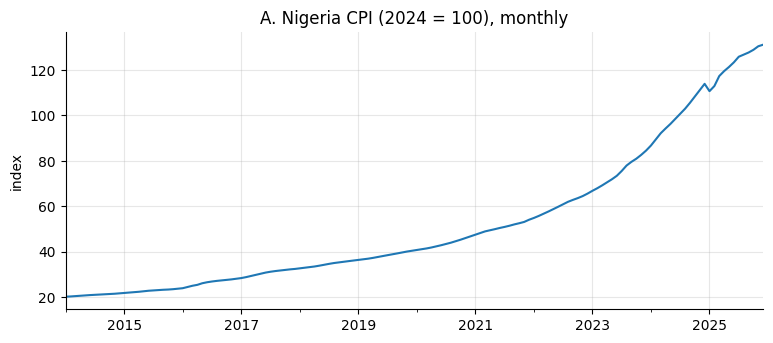

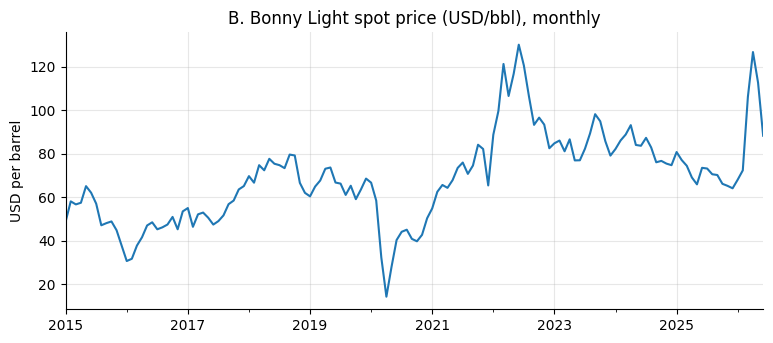

In [34]:
# Task 2a - time plots

print('Time Plots of Nigeria CPI and Bonny Light Spot Prices')
print(' ')
ax = cpi.plot(title='A. Nigeria CPI (2024 = 100), monthly'); ax.set_xlabel(''); ax.set_ylabel('index'); plt.show()
print(' ')
ax = bonny.plot(title='B. Bonny Light spot price (USD/bbl), monthly'); ax.set_xlabel(''); ax.set_ylabel('USD per barrel'); plt.show()


**Commentary - Time Plots:**

- **Nigeria CPI**: The CPI series shows a clear and steady upward trend from 2014 to 2025. The series rises fairly smoothly over the period, although the rate of increase varied across years and became much higher in later years (specifically around 2021 to 2023)

- **Bonny Light**: The Bonny Light series does not show a steady upward trend like the CPI series. Rather, it is highly volatile and had different highs and lows. Prices fell sharply around 2020, reaching a low of roughly 15 USD/bbl, before rising to a peak of around 130 USD/bbl in 2022. Prices then fluctuate mostly within a lower range between 2023 to 2025, before another sharp increase occured in 2026.

Seasonal Plots of Nigeria CPI and Bonny Light Spot Prices



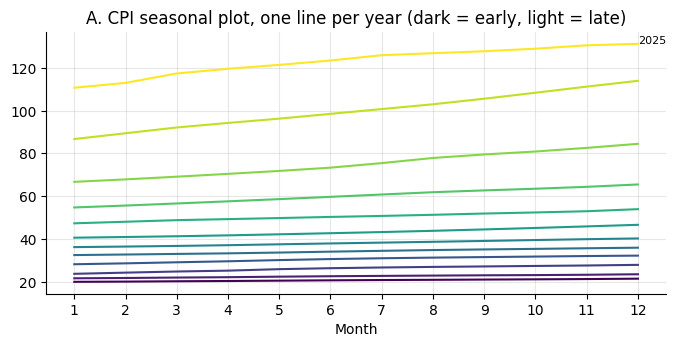

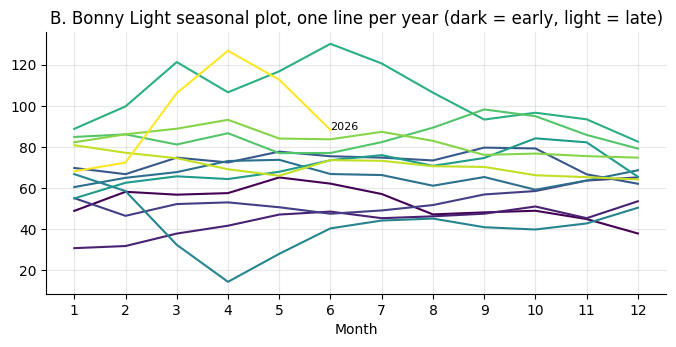

In [35]:
# Task 2b - seasonal plots

print('Seasonal Plots of Nigeria CPI and Bonny Light Spot Prices')
print('')
seasonal_plot(cpi,   title='A. CPI seasonal plot, one line per year (dark = early, light = late)'); plt.show()
print('')
seasonal_plot(bonny, title='B. Bonny Light seasonal plot, one line per year (dark = early, light = late)'); plt.show()


**Commentary - Seasonal Plots:**

- **Nigeria CPI**: The seasonal plot shows a strong upward movement across years, with later years consistently lying above earlier years. This mainly reflects the long-term upward trend in CPI and shows no clear evidence of a repeating seasonal pattern.
- **Bonny Light**: The Bonny Light series is quite noisy due to the large fluctuations of oil prices, making any repeating monthly pattern (seasonality) difficult to identify visually.

Seasonal Subseries Plots of Nigeria CPI and Bonny Light Spot Prices



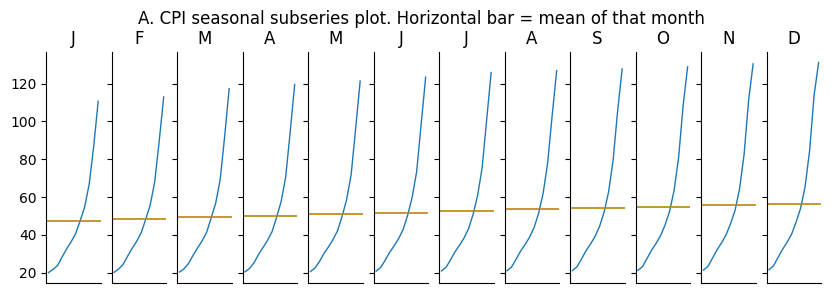

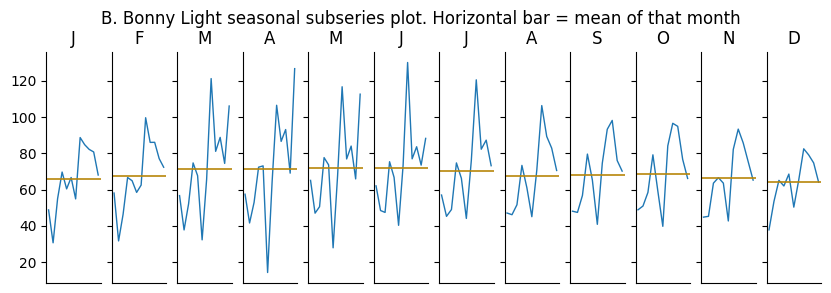

In [36]:
# Task 2c - seasonal subseries plots

print('Seasonal Subseries Plots of Nigeria CPI and Bonny Light Spot Prices')
print('')
subseries_plot(cpi,   'A. CPI seasonal subseries plot. Horizontal bar = mean of that month'); plt.show()
print('')
subseries_plot(bonny, 'B. Bonny Light seasonal subseries plot. Horizontal bar = mean of that month'); plt.show()


**Commentary - Seasonal Subseries Plots:**

- **Nigeria CPI**: The seasonal subseries plot shows the CPI values for each calendar month across the years. The monthly means (orange horizontal bars) increase consistently from January to December. This is mainly because CPI has a strong upward time trend, meaning that later months generally correspond to later points in time and therefore higher CPI levels. The increase from January to December may not necessarily be interpreted as evidence of seasonality.
- **Bonny Light**: The monthly means in the seasonal subseries plot for Bonny Light do not show a consistent pattern across the months. This reflects the substantial variability in oil prices across the years, which makes it difficult to identify a stable repeating monthly seasonal pattern.

Lag Plots of Nigeria CPI and Bonny Light Spot Prices



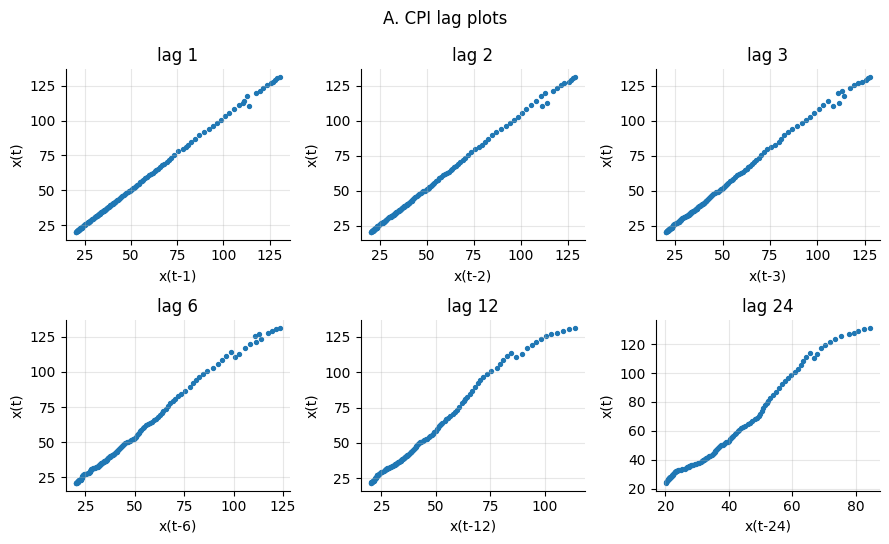

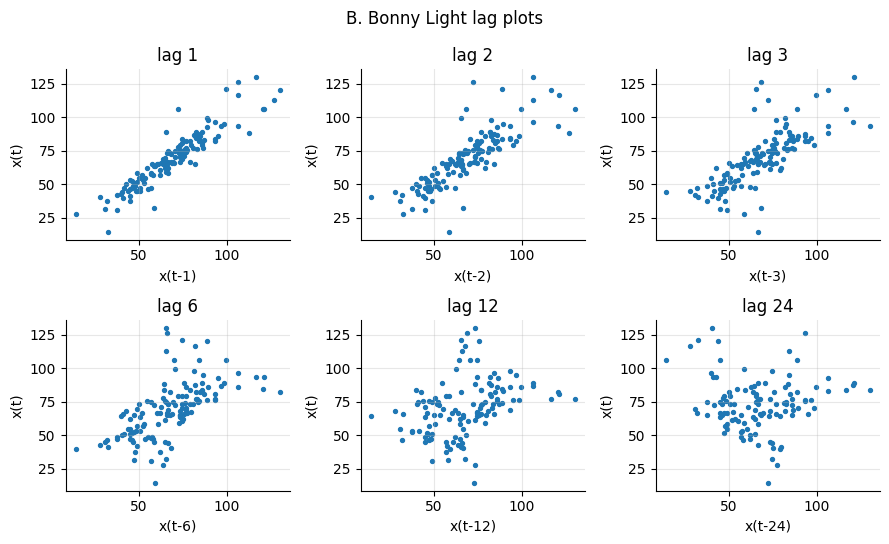

In [37]:
# Task 2d - lag plots

print('Lag Plots of Nigeria CPI and Bonny Light Spot Prices')
print('')
lag_plot_grid(cpi,   title='A. CPI lag plots'); plt.show()
print('')
lag_plot_grid(bonny, title='B. Bonny Light lag plots'); plt.show()


**Commentary - Lag Plots:**

- **Nigeria CPI**: The lag plots show a very strong positive relationship between the current CPI value (x_t) and its previous values (x_{t-1}, x_{t-2}, ...). This indicates strong serial dependence and persistence in the series. The strong relationship is expected because CPI changes gradually over time and has a strong upward trend.

- **Bonny Light**: The lag plots show considerably more scatter than the CPI lag plots, reflecting the greater volatility of oil prices. The points lie closer together at shorter lags. This shows weaker linear dependence between the current price and its lagged values.

## 3. ACF of each series and of its first difference

*plot_acf; interpret trend, seasonality, dependence*

Task: Plot the sample autocorrelation function of each series and of its first difference. Interpret what the ACF tells you about trend, seasonality and dependence.

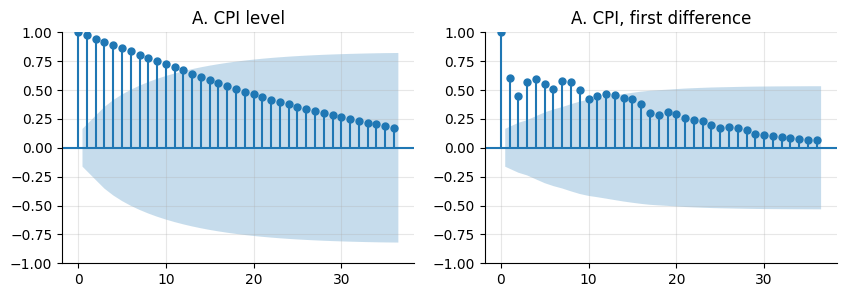

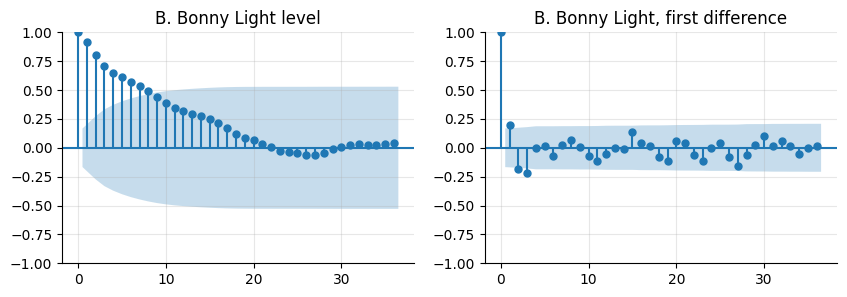

CPI level        Q(12) =   1245.64   p-value = 0.0000
CPI first diff   Q(12) =    503.15   p-value = 0.0000
Bonny level      Q(12) =    605.32   p-value = 0.0000
Bonny first diff Q(12) =     21.61   p-value = 0.0421


In [38]:
# Task 3 - ACF of each series and of its first difference
from statsmodels.graphics.tsaplots import plot_acf
d_cpi   = cpi.diff().dropna()
d_bonny = bonny.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(cpi,   lags=36, ax=axes[0], title='A. CPI level')
plot_acf(d_cpi, lags=36, ax=axes[1], title='A. CPI, first difference')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(bonny,   lags=36, ax=axes[0], title='B. Bonny Light level')
plot_acf(d_bonny, lags=36, ax=axes[1], title='B. Bonny Light, first difference')
plt.show()

# - Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox
for name, s_ in [('CPI level', cpi), ('CPI first diff', d_cpi), ('Bonny level', bonny), ('Bonny first diff', d_bonny)]:
    q = acorr_ljungbox(s_, lags=[12], return_df=True)
    print(f'{name:16s} Q(12) = {q.lb_stat.iloc[0]:9.2f}   p-value = {q.lb_pvalue.iloc[0]:.4f}')


**Commentary:**

- **Nigeria CPI**: The CPI level is trend-dominated, with the ACF showing a slow fade and strong positive autocorrelation persisting across many lags. This reflects the strong upward trend in the series as nearby observations tend to have similar values. After first differencing, the ACF declined more quickly, showing that differencing reduced the influence of the trend. However, the differenced series still showed strong, slowly decaying persistence, meaning that monthly CPI changes remained related across several months. There are no clear spikes at lags 12, 24, or 36, so there is no strong evidence of annual seasonality.

- **Bonny Light**: The Bonny Light level also shows a slowly decaying ACF, indicating persistence in monthly oil prices, although the dependence weakens more quickly than for CPI. After first differencing, most ACF values fell within the confidence band, with only a few short-lag correlations remaining. This indicates that differencing substantially reduced the persistence in the series. There are no clear spikes at lags 12, 24, or 36, hence annual seasonality is not evident. The Ljung-Box test for the first difference gives (Q(12)=21.61\), (p=0.0421), indicating that some dependence remains across the first 12 lags despite the weaker individual autocorrelations.

## 4. Additive or multiplicative? Justify

*evidence from the plots and the log plot*

Task: Decide whether an additive or a multiplicative structure is more appropriate for each series and justify the decision with evidence from the plots.

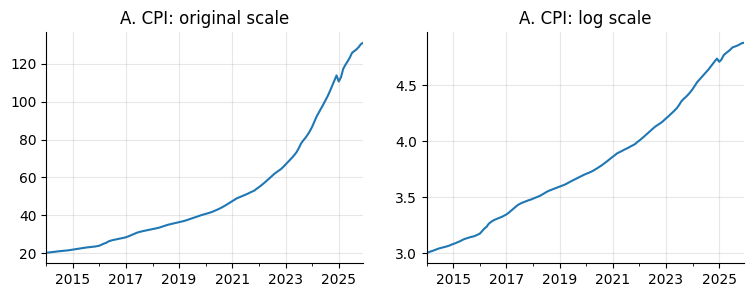

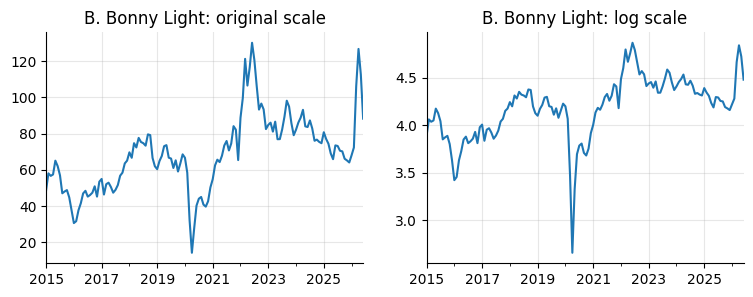

In [39]:
# Task 4 - original vs log scale

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
cpi.plot(ax=axes[0], title='A. CPI: original scale')
np.log(cpi).plot(ax=axes[1], title='A. CPI: log scale')
for ax in axes: ax.set_xlabel('')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
bonny.plot(ax=axes[0], title='B. Bonny Light: original scale')
np.log(bonny).plot(ax=axes[1], title='B. Bonny Light: log scale')
for ax in axes: ax.set_xlabel('')
plt.show()


**Commentary:**

The Nigerian CPI series is multiplicative. **Evidence**: On the original scale, the changes become larger as the CPI level increases, while on the log scale the changes become roughly constant in amplitude.

The Bonny Light series is also multiplicative. **Evidence**: On the original scale, the price swings vary substantially with the level of the series, while on the log scale the swings become roughly constant in amplitude.

## 5. Classical and STL decomposition compared

*seasonal_decompose vs STL; where do they disagree and why*

Task: Apply a classical decomposition and an STL decomposition to each series. Compare the trend and seasonal components and comment on where they disagree and why.

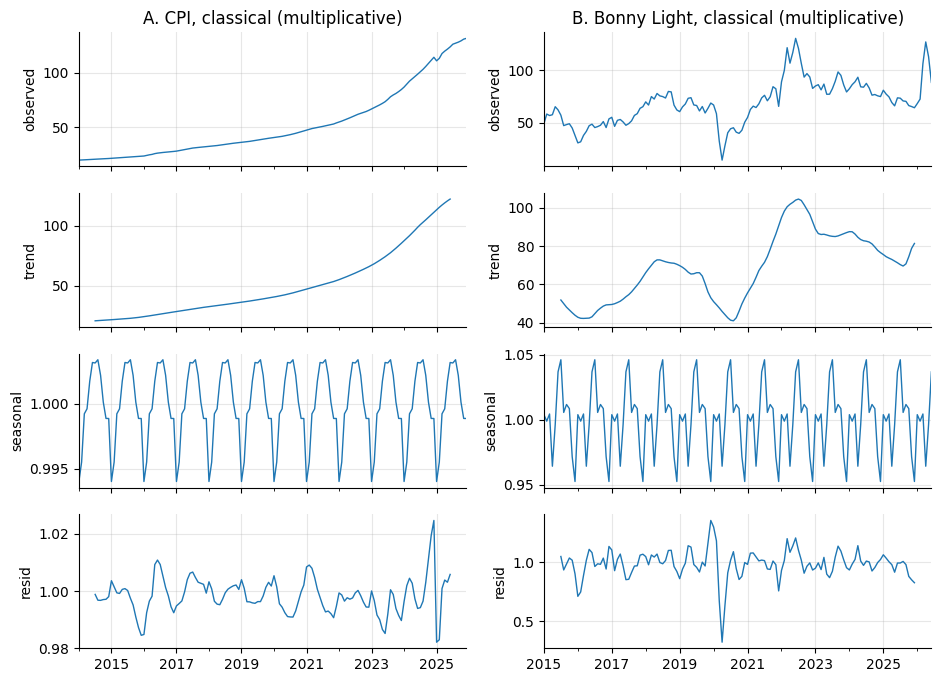

In [40]:
# Task 5a - classical decomposition

from statsmodels.tsa.seasonal import seasonal_decompose, STL
MODEL_A = 'multiplicative'
MODEL_B = 'multiplicative'

dec_a = seasonal_decompose(cpi,   model=MODEL_A, period=12)
dec_b = seasonal_decompose(bonny, model=MODEL_B, period=12)

fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharex='col')
for col, (dec, name) in enumerate([(dec_a, f'A. CPI, classical ({MODEL_A})'), (dec_b, f'B. Bonny Light, classical ({MODEL_B})')]):
    for row, comp in enumerate(['observed', 'trend', 'seasonal', 'resid']):
        getattr(dec, comp).plot(ax=axes[row, col], lw=1); axes[row, col].set_ylabel(comp); axes[row, col].set_xlabel('')
    axes[0, col].set_title(name)
plt.show()


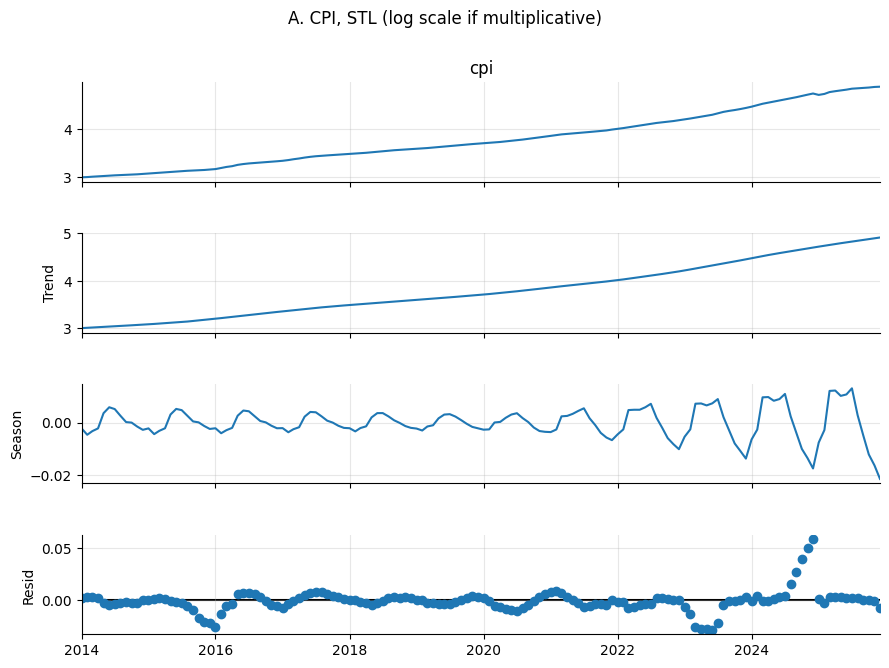

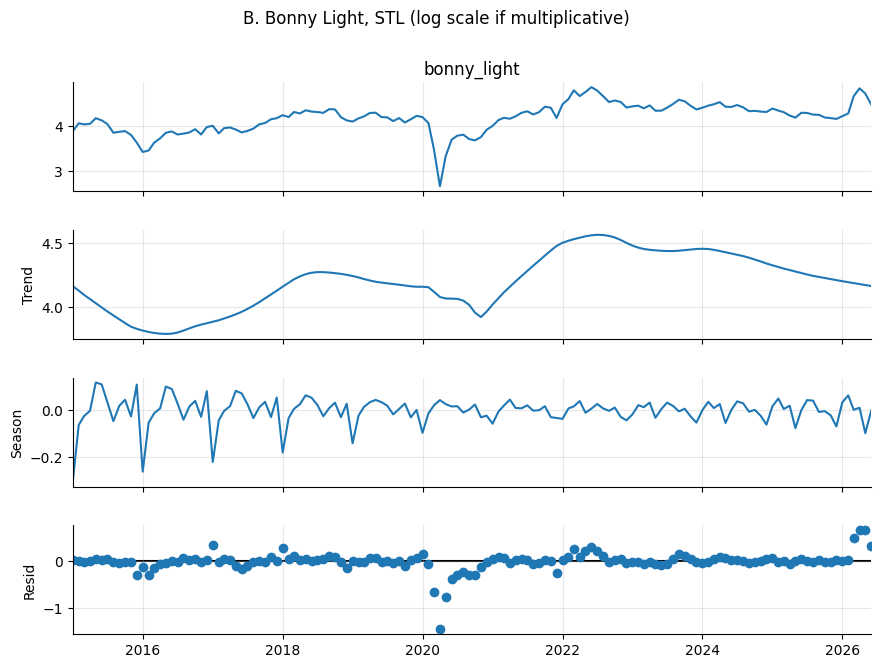

In [41]:
# Task 5b - STL decomposition

y_a = np.log(cpi)   if MODEL_A == 'multiplicative' else cpi
y_b = np.log(bonny) if MODEL_B == 'multiplicative' else bonny
stl_fit_a = STL(y_a, period=12, seasonal=13, robust=True).fit()
stl_fit_b = STL(y_b, period=12, seasonal=13, robust=True).fit()

fig = stl_fit_a.plot(); fig.set_size_inches(9, 7); fig.suptitle('A. CPI, STL (log scale if multiplicative)', y=1.0); plt.show()
print('')
print('')
fig = stl_fit_b.plot(); fig.set_size_inches(9, 7); fig.suptitle('B. Bonny Light, STL (log scale if multiplicative)', y=1.0); plt.show()


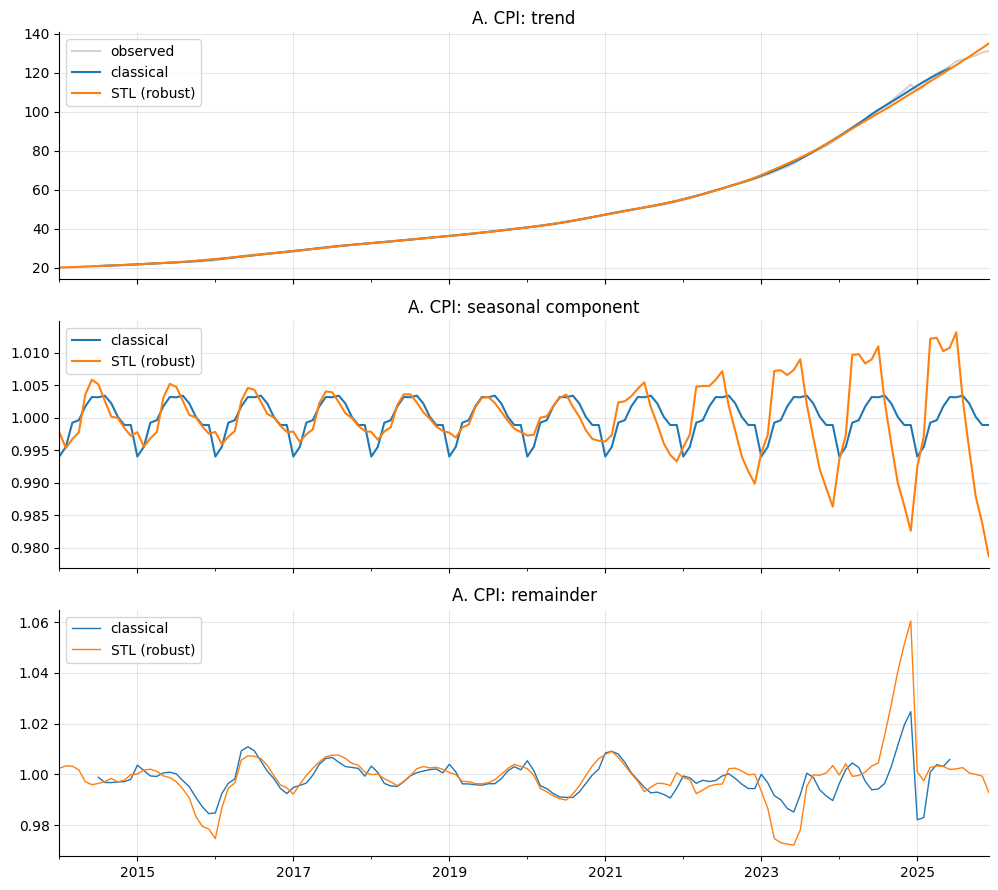

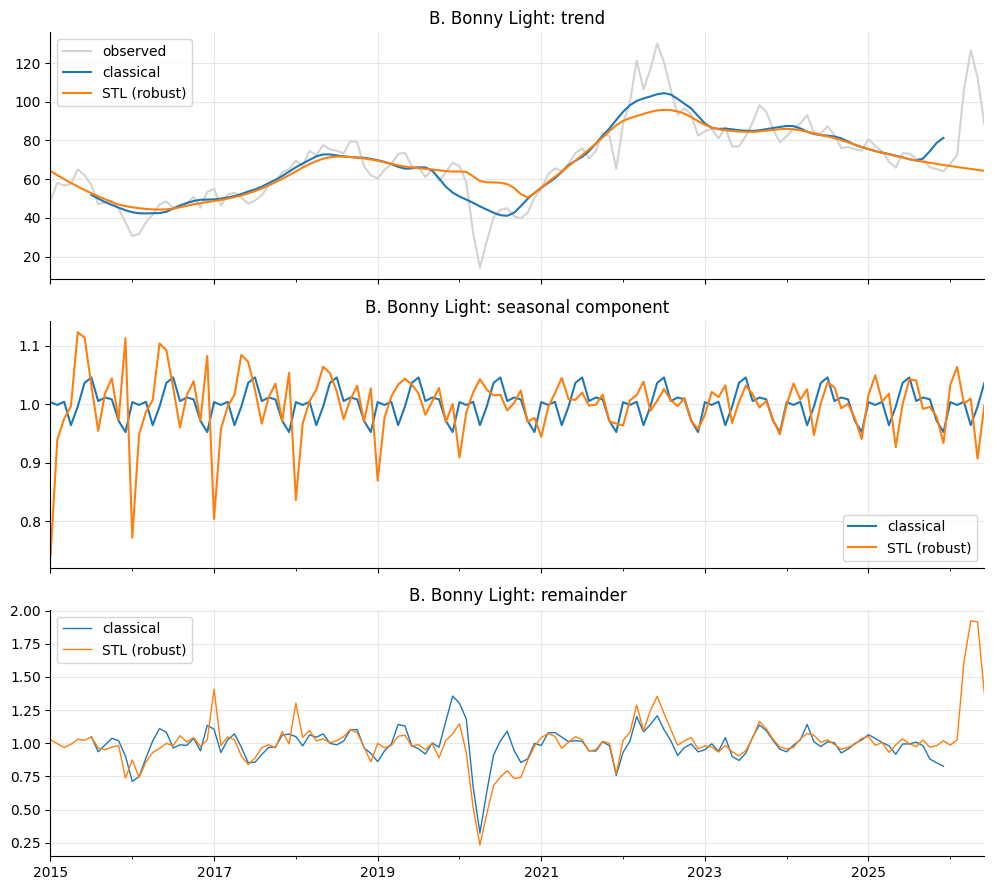

In [42]:
# Task 5c - compare classical and STL on the ORIGINAL scale (exponentiate STL if it was fitted to logs, as in Lab 3 exercise / Lab 4)
def stl_on_original_scale(fit, model):
    back = np.exp if model == 'multiplicative' else (lambda x: x)
    return pd.DataFrame({'trend': back(fit.trend), 'seasonal': back(fit.seasonal), 'resid': back(fit.resid)})

stl_a = stl_on_original_scale(stl_fit_a, MODEL_A)
stl_b = stl_on_original_scale(stl_fit_b, MODEL_B)

def compare_plot(s, dec, stl, name):
    fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
    s.plot(ax=axes[0], color='lightgray', label='observed')
    dec.trend.plot(ax=axes[0], label='classical'); stl['trend'].plot(ax=axes[0], label='STL (robust)')
    axes[0].set_title(f'{name}: trend'); axes[0].legend()
    dec.seasonal.plot(ax=axes[1], label='classical'); stl['seasonal'].plot(ax=axes[1], label='STL (robust)')
    axes[1].set_title(f'{name}: seasonal component'); axes[1].legend()
    dec.resid.plot(ax=axes[2], label='classical', lw=1); stl['resid'].plot(ax=axes[2], label='STL (robust)', lw=1)
    axes[2].set_title(f'{name}: remainder'); axes[2].legend()
    for ax in axes: ax.set_xlabel('')
    plt.tight_layout(); plt.show()
    print('')
    print('')

compare_plot(cpi,   dec_a, stl_a, 'A. CPI')
compare_plot(bonny, dec_b, stl_b, 'B. Bonny Light')


In [43]:
# Where does each method have no trend estimate?
for name, dec, stl in [('A. CPI', dec_a, stl_a), ('B. Bonny Light', dec_b, stl_b)]:
    print(f'{name}: classical trend valid from {dec.trend.first_valid_index():%b %Y} to {dec.trend.last_valid_index():%b %Y} | STL covers {stl.index[0]:%b %Y} to {stl.index[-1]:%b %Y}')


A. CPI: classical trend valid from Jul 2014 to Jun 2025 | STL covers Jan 2014 to Dec 2025
B. Bonny Light: classical trend valid from Jul 2015 to Dec 2025 | STL covers Jan 2015 to Jun 2026


**Commentary**:

The classical and STL decompositions produced broadly similar trend components in the middle of both series but differed more at the ends and around periods of unusual movements. **For CPI**, the classical trend was valid only from July 2014 to June 2025, compared with January 2014 to December 2025 for STL. **For Bonny Light**, the classical trend covered July 2015 to December 2025, while STL covered January 2015 to June 2026. These differences demonstrate the **end-loss weakness** of classical decomposition.

The seasonal components also differ because classical decomposition imposed an identical seasonal pattern every year, whereas STL allowed the seasonal pattern to evolve. This is particularly visible for CPI from around 2022 onward, where the STL seasonal component showed increasing amplitude and larger deviations, while the classical seasonal component continued to repeat the same pattern throughout the sample. For Bonny Light, the STL seasonal component also varied considerably from year to year, especially around 2015 - 2020, whereas the classical component imposed the same monthly pattern across all years. These differences illustrate the **frozen-seasonality weakness** of classical decomposition.

The **lack-of-robustness weakness** is most evident for Bonny Light around the 2020 price collapse: the classical trend dropped sharply toward the extreme observation and then quickly reversed, whereas the robust STL trend remained smoother and less affected by the collapse. The corresponding classical remainder also showed a very large deviation around 2020, while the STL remainder was less distorted.

## 6. Transformation decision

*log / Box-Cox; show the effect*

Task: Decide whether a transformation (log or Box–Cox) is warranted; if so apply it and show the effect on the decomposition.

In [44]:
# Task 6 - Box-Cox and log
from scipy import stats
lam_cpi   = stats.boxcox_normmax(cpi.values,   method='mle')
lam_bonny = stats.boxcox_normmax(bonny.values, method='mle')
print(f'MLE Box-Cox lambda: CPI = {lam_cpi:.3f} | Bonny Light = {lam_bonny:.3f}  (0 = log)')

def three_scales(s, lam):
    return {'original (lambda = 1)': s,
            'log (lambda = 0)': np.log(s),
            f'Box-Cox (lambda = {lam:.2f})': pd.Series(stats.boxcox(s.values, lmbda=lam), index=s.index)}


MLE Box-Cox lambda: CPI = -0.429 | Bonny Light = 0.657  (0 = log)


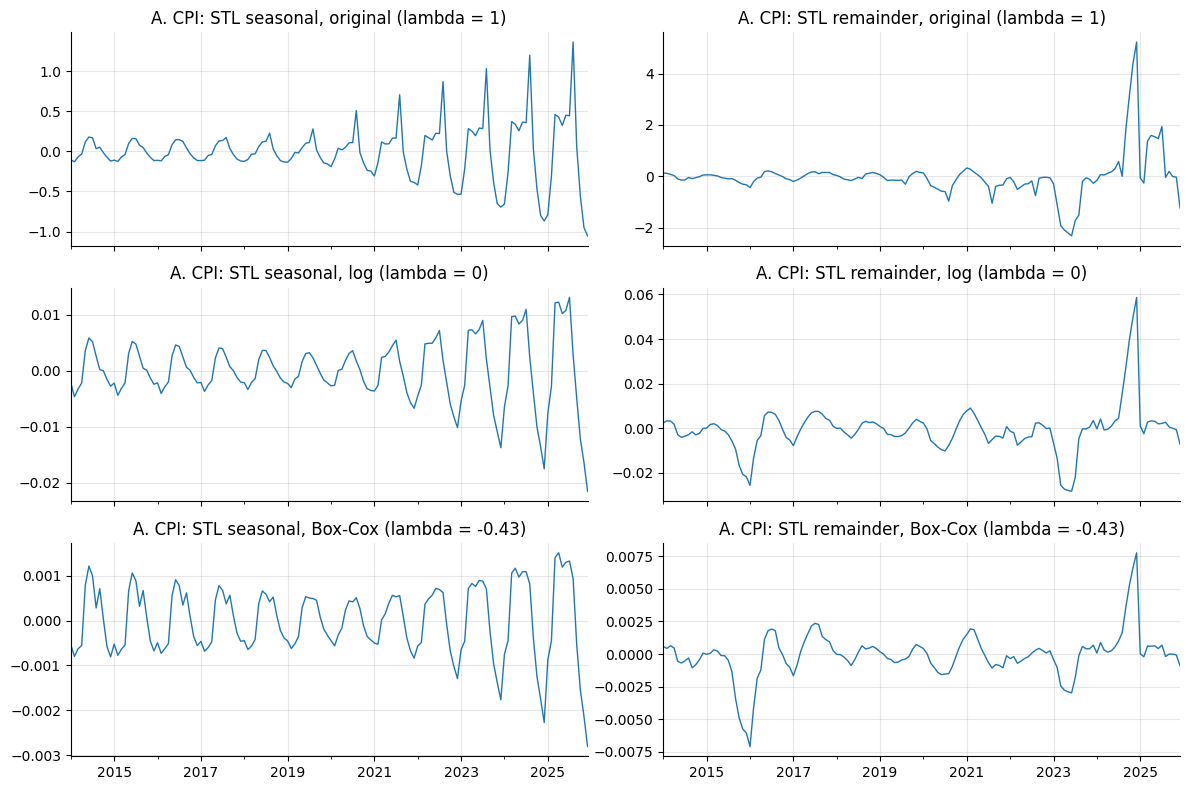



A. CPI: remainder std, first half vs second half of the sample
   original (lambda = 1)            0.1415     1.2188   ratio =   8.61
   log (lambda = 0)                 0.0064     0.0137   ratio =   2.14
   Box-Cox (lambda = -0.43)         0.0018     0.0017   ratio =   0.99





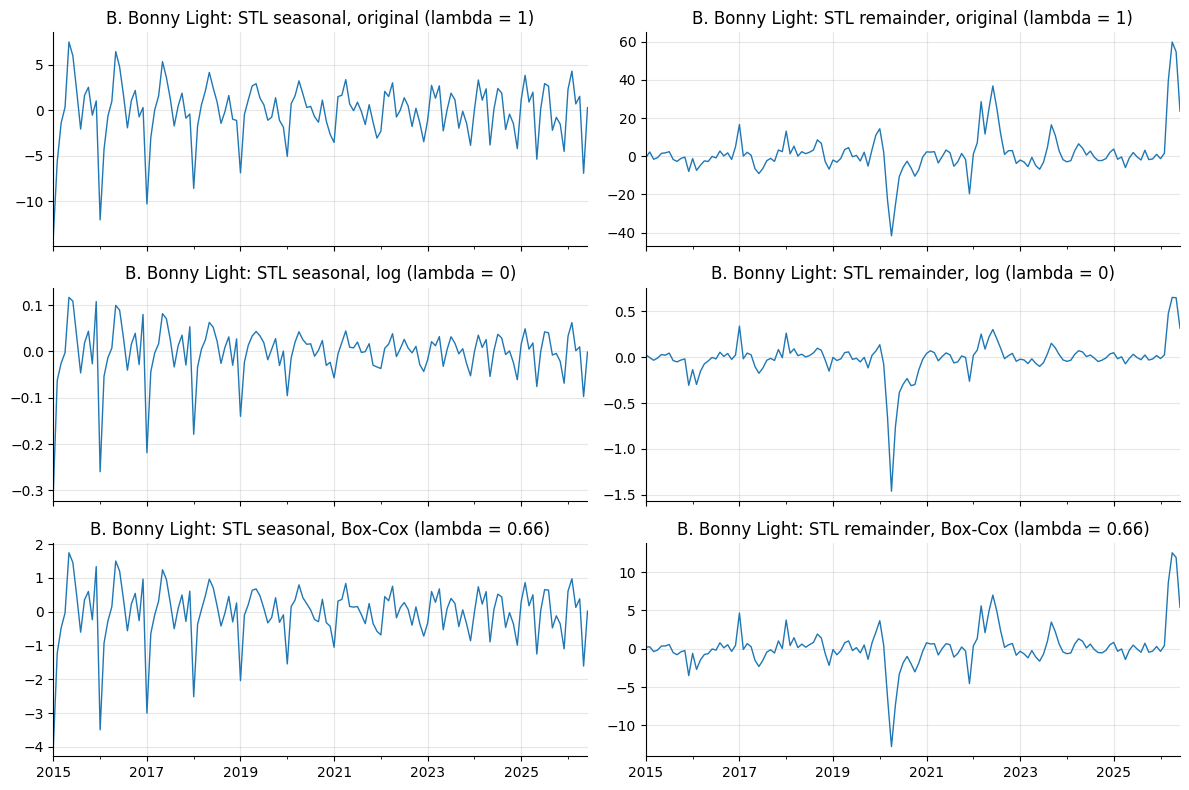



B. Bonny Light: remainder std, first half vs second half of the sample
   original (lambda = 1)            8.1941    13.5675   ratio =   1.66
   log (lambda = 0)                 0.2380     0.1551   ratio =   0.65
   Box-Cox (lambda = 0.66)          2.3578     2.8807   ratio =   1.22





In [45]:
# Task 6 - effect on the decomposition: STL seasonal (left) and remainder (right) on each scale

for tag, s, lam in [('A. CPI', cpi, lam_cpi), ('B. Bonny Light', bonny, lam_bonny)]:
    fits = {k: STL(v, period=12, seasonal=13, robust=True).fit() for k, v in three_scales(s, lam).items()}
    fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
    for row, (k, f) in enumerate(fits.items()):
        f.seasonal.plot(ax=axes[row, 0], lw=1); axes[row, 0].set_title(f'{tag}: STL seasonal, {k}')
        f.resid.plot(ax=axes[row, 1], lw=1);    axes[row, 1].set_title(f'{tag}: STL remainder, {k}')
        for ax in axes[row]: ax.set_xlabel('')
    plt.tight_layout(); plt.show()
    print('')
    print('')


    # - remainder
    print(f'{tag}: remainder std, first half vs second half of the sample')
    for k, f in fits.items():
        h = len(f.resid) // 2; a, b = f.resid.iloc[:h].std(), f.resid.iloc[h:].std()
        print(f'   {k:28s} {a:10.4f} {b:10.4f}   ratio = {b / a:6.2f}')
    print()
    print('')
    print('')

# Decisions
LOG_CPI   = True
LOG_BONNY = True


**Commentary**:

- A transformation was warranted for the Nigeria CPI, as the original-scale remainder ratio was 8.61. The log transformation reduced this to 2.14, while Box-Cox with λ = -0.43 reduced it further to 0.99, providing stronger variance stabilisation. The log transformation was selected, however, because it is more interpretable and consistent with the multiplicative structure earlier identified in Task 4. It also reduced the amplitude of the seasonal and remainder components, although some variation in the remainder spread remained.

- For Bonny Light, the need for transformation was less strong, with an original-scale remainder ratio of 1.66. The log transformation gave a ratio of 0.65, while Box-Cox with λ = 0.66 gave 1.22, indicating that Box-Cox provided more balanced variance across the two periods. However, this comparison was sensitive to the 2020 price collapse, which affected the first-half remainder spread. The log transformation was therefore used as a simpler and more interpretable choice. On the log scale, the seasonal component remained relatively small and the remainder was generally centred around zero, apart from the major price movements around 2020 and later in the series.




## 7. Seasonally adjusted series

*adjust on the right scale*

Task: Produce and plot the seasonally adjusted version of each series.

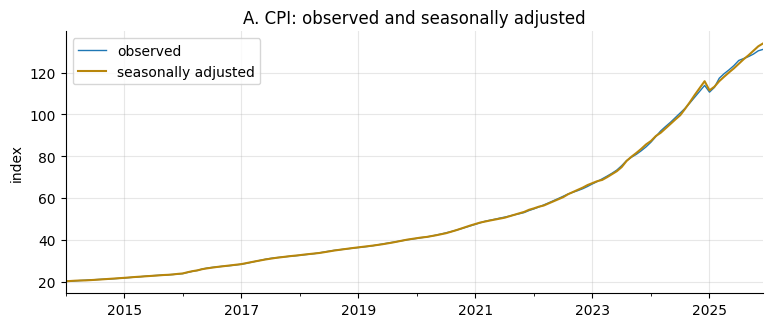

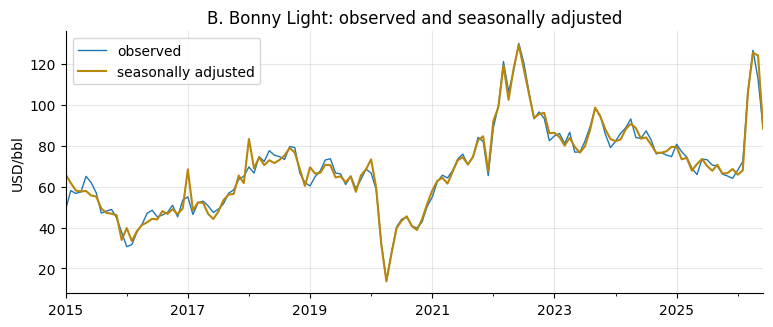

In [50]:
# Task 7 - seasonal adjustment and plot
# multiplicative: divide by the seasonal factor; additive: subtract
def seasonally_adjust(s, stl_df, model):
    return s / stl_df['seasonal'] if model == 'multiplicative' else s - stl_df['seasonal']

cpi_sa   = seasonally_adjust(cpi,   stl_a, MODEL_A)
bonny_sa = seasonally_adjust(bonny, stl_b, MODEL_B)

for tag, s, sa, unit in [('A. CPI', cpi, cpi_sa, 'index'), ('B. Bonny Light', bonny, bonny_sa, 'USD/bbl')]:
    ax = s.plot(figsize=(9, 3.4), lw=1, label='observed')
    sa.plot(ax=ax, lw=1.5, color='#B8860B', label='seasonally adjusted')
    ax.set_title(f'{tag}: observed and seasonally adjusted'); ax.set_ylabel(unit); ax.legend(); ax.set_xlabel(''); plt.show()
    print('')


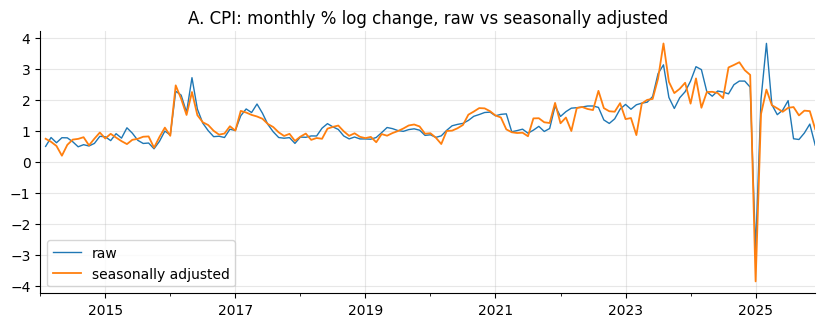

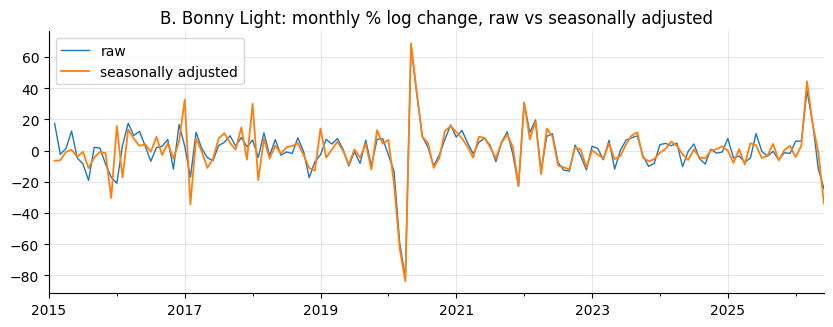



A. CPI seasonal factors, last 12 months (multiplicative):
date
2025-01-01    0.9924
2025-02-01    0.9971
2025-03-01    1.0121
2025-04-01    1.0123
2025-05-01    1.0102
2025-06-01    1.0108
2025-07-01    1.0131
2025-08-01    1.0028
2025-09-01    0.9950
2025-10-01    0.9879
2025-11-01    0.9838
2025-12-01    0.9787
Freq: MS

B. Bonny Light seasonal factors, last 12 months (multiplicative):
date
2025-07-01    1.0430
2025-08-01    1.0407
2025-09-01    0.9921
2025-10-01    0.9956
2025-11-01    0.9785
2025-12-01    0.9335
2026-01-01    1.0331
2026-02-01    1.0641
2026-03-01    1.0014
2026-04-01    1.0097
2026-05-01    0.9070
2026-06-01    0.9984
Freq: MS


In [52]:
# Task 7 - seasonally adjusted series on monthly % log change, raw vs adjusted
for tag, s, sa in [('A. CPI', cpi, cpi_sa), ('B. Bonny Light', bonny, bonny_sa)]:
    raw_chg, sa_chg = 100 * np.log(s).diff(), 100 * np.log(sa).diff()
    ax = raw_chg.plot(figsize=(10, 3.4), lw=1, label='raw')
    sa_chg.plot(ax=ax, lw=1.3, label='seasonally adjusted')
    ax.set_title(f'{tag}: monthly % log change, raw vs seasonally adjusted'); ax.legend(); ax.set_xlabel(''); plt.show()
    print('')

print('')
print('A. CPI seasonal factors, last 12 months (' + MODEL_A + '):');          print(stl_a['seasonal'].iloc[-12:].round(4).to_string())
print('\nB. Bonny Light seasonal factors, last 12 months (' + MODEL_B + '):'); print(stl_b['seasonal'].iloc[-12:].round(4).to_string())


**Commentary:**

The seasonal adjustment was performed on the log scale because the series were identified as multiplicative in Task 4. The estimated seasonal component was subtracted from the log-transformed series, and the result was exponentiated to return to the original scale. This removes the estimated seasonal effect while preserving the underlying trend and other non-seasonal movements.

For Nigeria CPI, the observed and seasonally adjusted level series are very close throughout the sample. The seasonal factors for the final 12 months ranged from 0.9787 to 1.0131, corresponding to adjustments of roughly ±2% relative to the observed level. This is small compared with the overall CPI level and its strong upward trend. In the monthly log-change plot, the raw and adjusted series are also very close, with a median gap of about 0.15 percentage points compared with a typical monthly change of about 1.11%. The larger divergence around January 2025 coincides with a sharp movement in the CPI series, so the flexible STL seasonal estimate around this point should be interpreted with some caution. The seasonal-strength measure in Task 8 was 0.000, providing no strong evidence of a substantial seasonal pattern.

For Bonny Light, the observed and seasonally adjusted level series are also generally close, although the adjustment is more visible than for CPI. The seasonal factors for the final 12 months ranged from 0.9070 to 1.0641, while the full-sample factors ranged from about 0.74 to 1.12. In the monthly log-change plot, the largest differences occur around January 2016, January 2017, February 2015, and January 2018, where the seasonal factor changes sharply between adjacent months. For monthly changes, the gap is therefore determined by the change in the seasonal factor between consecutive months, rather than simply by how far an individual factor is from 1. The median gap is about 3.4 percentage points compared with a typical monthly change of about 6.9%, so the seasonal adjustment can represent a meaningful part of an ordinary monthly movement even though it is small relative to major price shocks. The seasonal-strength measure of 0.000 in Task 8 nevertheless indicates no strong evidence of a stable seasonal pattern.

A manager would use the seasonally adjusted series when the objective is to assess underlying movements after removing estimated seasonal effects. For CPI, the adjustment has little effect relative to the overall level and long-term trend. For Bonny Light, it can have a more noticeable effect relative to a typical monthly price change, but it does not remove irregular shocks such as the 2020 price collapse or the large movements in 2022 and 2026.

## 8. Strength of trend and seasonality

*compute for both series and compare*

Task: Compute the strength-of-trend and strength-of-seasonality features for both series and use them to compare the two.

In [48]:
def strength_features(s, period, log=False, seasonal=13):
    """Lecture 4 / Lab 4 definitions: F = max(0, 1 - Var(R) / Var(component + R)), from a robust STL fit."""
    y = np.log(s) if log else s
    r = STL(y, period=period, seasonal=seasonal, robust=True).fit()
    ft = float(max(0, 1 - r.resid.var() / (r.trend + r.resid).var()))
    fs = float(max(0, 1 - r.resid.var() / (r.seasonal + r.resid).var()))
    return round(ft, 3), round(fs, 3)

# A white-noise series as a yardstick: by construction it has no trend and no seasonality
wn = pd.Series(np.random.default_rng(3).normal(size=144), index=cpi.index)

rows = []
for name, s, lg in [("A. Nigeria CPI", cpi, LOG_CPI), ("B. Bonny Light", bonny, LOG_BONNY), ("White noise (yardstick)", wn, False)]:
    ft, fs = strength_features(s, 12, log=lg); rows.append((name, lg, ft, fs))
print(pd.DataFrame(rows, columns=["series", "log used", "trend strength", "seasonal strength"]).to_string(index=False))

# Sensitivity: how much do the seasonal-strength numbers depend on the STL seasonal window?
print("\nSeasonal strength for different STL seasonal windows (odd numbers; small = the pattern may change quickly):")
for name, s, lg in [("A. Nigeria CPI", cpi, LOG_CPI), ("B. Bonny Light", bonny, LOG_BONNY)]:
    print(f"   {name:16s}", {w: strength_features(s, 12, log=lg, seasonal=w)[1] for w in (7, 13, 25)})


                 series  log used  trend strength  seasonal strength
         A. Nigeria CPI      True           1.000              0.000
         B. Bonny Light      True           0.603              0.000
White noise (yardstick)     False           0.045              0.128

Seasonal strength for different STL seasonal windows (odd numbers; small = the pattern may change quickly):
   A. Nigeria CPI   {7: 0.0, 13: 0.0, 25: 0.0}
   B. Bonny Light   {7: 0.053, 13: 0.0, 25: 0.0}


**Commentary:**

The strength-of-trend and strength-of-seasonality measures were computed from a robust STL fit on the log scale, using a seasonal period of 12 and a seasonal window of 13. The measures are unit-free, making them comparable across the two series. Trend strength is calculated as \(1 - Var(R) / Var(T + R)), while seasonal strength is (1 - Var(R) / Var(S + R)). Values near 1 indicate a strong component, while values near 0 indicate that the component does not stand out from the remainder.

Nigeria CPI has a trend strength of 1.000, indicating a very strong slow-moving component, while Bonny Light has a lower value of 0.603. This agrees with Tasks 2 and 3: CPI was strongly trend-dominated, whereas Bonny Light was more volatile and showed slower swings between periods such as the 2016 low and 2022 peak. Thus, the 0.603 value for Bonny Light indicates substantial slow-moving structure rather than a steady directional trend. Both series have a seasonal strength of 0.000, consistent with the absence of clear repeating annual patterns in the seasonal plots and ACFs.

The seasonal-strength window check gives 0.000 for CPI across all three windows and 0.053, 0.000, and 0.000 for Bonny Light with windows 7, 13, and 25 respectively. This suggests that allowing the seasonal component to change more rapidly captures only a small amount of additional variation for Bonny Light.

The single white-noise yardstick series gives a trend strength of 0.045 and seasonal strength of 0.128, illustrating the levels that can arise from noise alone. The seasonal strength of 0.000 for both series therefore provides no evidence of a meaningful seasonal component. The much higher trend-strength values indicate that both series contain more slow-moving structure than this noise example, although the measure does not by itself establish a steady directional trend.

Bonny Light's seasonal factors can still deviate noticeably from 1 even with a seasonal strength of 0.000. Over the full sample, the factors range from about 0.74 to 1.12, but these deviations do not stand out as a stable repeating seasonal pattern. This illustrates why the strength measure is more informative than individual seasonal factors when assessing whether seasonality is systematic and substantial.

## 9. Narratives (one page per series, also in the PDF report)

*what the series is doing; regularities; events or breaks; what a forecaster should worry about*

Task: Write a one-page narrative for each series (two pages in total) addressed to a manager: what the series is doing, what is regular and what is not, what events or breaks are visible, and what a forecaster should be careful about.

Page 1:

A. Nigeria CPI

Nigeria's CPI shows a strong and persistent upward movement over the period from January 2014 to December 2025. The series is strongly trend-dominated, with a trend-strength measure of 1.000, and the level ACF shows high persistence that declines slowly across lags. The CPI rises fairly smoothly through much of the sample, with the rate of increase becoming more pronounced in the later years. The level also becomes more volatile as it rises, which supports the use of a log transformation. On the log scale, the changes become more stable, although some variation remains. First differencing substantially reduces the persistence associated with the level trend, but some dependence remains across several months.

There is no strong evidence of a stable seasonal pattern. The seasonal-strength measure is 0.000, and the ACF does not show clear spikes at the annual lags of 12, 24, or 36 months. The seasonal subseries plot also does not provide convincing evidence of a repeating monthly pattern; the apparent increase in monthly means from January to December is largely explained by the underlying upward trend. The STL seasonal factors are small relative to the CPI level, with the final 12 months ranging from 0.9787 to 1.0131, corresponding to adjustments of roughly ±2%. Thus, seasonality is not an important driver of the overall CPI movement.

The main feature a forecaster should be aware of is the changing rate of increase and the unusual movement around 2025. The observed and seasonally adjusted series remain very close, but their difference becomes more visible around January 2025. This period should be treated cautiously when interpreting the flexible STL seasonal component because an unusual movement can influence the estimated components. More broadly, the strong persistence and changing level mean that a model fitted to the raw CPI level could easily mistake the long-term movement for short-term dependence.

For forecasting, the log scale is appropriate because the series behaves more like a multiplicative process, while differencing can be used to reduce the strong persistence in the level. A forecaster should therefore avoid assuming that the historical rate of increase will continue unchanged into the future. The absence of strong seasonality also means that a complex seasonal component is unlikely to add much value. The main forecasting challenge is instead the persistent trend and changes in the rate of growth, together with the possibility that unusual recent movements may not follow the historical pattern.

Page 2:

B. Bonny Light

Bonny Light behaves very differently from Nigeria CPI. Rather than following a persistent upward movement, the series is characterised by high volatility and large movements between different periods. Prices fell sharply around 2020 to roughly $15/bbl, rose rapidly to around $130/bbl in 2022, and then fluctuated through a lower range during 2023–2025 before another sharp increase in 2026. The trend-strength measure is 0.603, which indicates substantial slow-moving structure, but this should not be interpreted as evidence of a steady directional trend. The series is better described as moving through broad swings and episodes of different price levels.

Short-term dependence is present, particularly in the level series. The ACF declines gradually, showing that nearby monthly prices tend to remain related, but this dependence is much weaker than for CPI. After first differencing, most ACF values fall within the confidence bands, showing that differencing substantially reduces the persistence. This suggests that a large part of the dependence in the price level comes from the fact that oil prices tend to remain around similar levels for periods before moving to a different level.

There is also no strong evidence of stable annual seasonality. The seasonal-strength measure is 0.000, and the ACF has no clear annual spikes at lags 12, 24, or 36. The STL window check gives 0.000 for windows 13 and 25 and only 0.053 for the more flexible window of 7. This suggests that a small amount of short-term variation can be captured as seasonal when the seasonal pattern is allowed to change rapidly, but there is no consistent repeating monthly pattern. The seasonal factors can nevertheless move away from 1, particularly early in the sample, showing why individual seasonal factors should not be interpreted as evidence of systematic seasonality.

The main forecasting concern is therefore irregular shocks and changes in the price regime, rather than seasonality. The 2020 collapse and the strong rise into 2022 demonstrate that extreme movements can dominate the series and substantially affect decomposition and variance estimates. The large movements in 2026 provide another reminder that recent behaviour can differ considerably from earlier periods. A model based only on historical short-term dependence may therefore struggle when a new price shock occurs.

For forecasting, the log transformation helps account for the changing scale of price movements, while first differencing substantially reduces persistence. However, neither transformation removes unexpected market shocks. A forecaster should therefore place more emphasis on recent price behaviour, volatility and potential structural changes than on a fixed seasonal pattern. Forecast uncertainty should also be treated as important, particularly when projecting beyond the short term, because the historical series contains large movements that are difficult to anticipate from the time series alone.

## AI-use statement

(Two to five lines: which tools, for what. 'No AI tools were used' is acceptable.)